## Basic Pitch on PianoVAM

Imports

In [1]:
from pathlib import Path
from huggingface_hub import snapshot_download
import json
import time
import contextlib
import io
import gc

import matplotlib.pyplot as plt
import mir_eval
import numpy as np
import pandas as pd

from basic_pitch import ICASSP_2022_MODEL_PATH
from basic_pitch.constants import AUDIO_SAMPLE_RATE, FFT_HOP
from basic_pitch.inference import Model, predict, run_inference
from basic_pitch.note_creation import model_output_to_notes
from evaluation_function.compare_MIDI import compare_performance_ED
from tqdm import tqdm

/Users/jz7125/compareMusic/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
scikit-learn version 1.9.0 is not supported. Minimum required version: 0.17. Maximum required version: 1.5.1. Disabling scikit-learn conversion API.
/Users/jz7125/compareMusic/.venv/lib/python3.11/site-packages/resampy/filters.py:50: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Download dataset

In [2]:
# Directory where the PianoVAM dataset will be stored
DATA_ROOT = Path("data/PianoVAM_v1")

if DATA_ROOT.exists():
    print("PianoVAM dataset already exists.")
else:
    print("Downloading PianoVAM dataset...")
    snapshot_download(
        repo_id="PianoVAM/PianoVAM_v1",
        repo_type="dataset",
        local_dir=DATA_ROOT,
        allow_patterns=[
            "Audio/**",
            "MIDI/**",
            "TSV/**",
            "metadata.json",
            "README.md",
        ],
    )
    print("Download complete.")

PianoVAM dataset already exists.


Configuration

In [3]:
# PianoVAM paths
AUDIO_DIR = DATA_ROOT / "Audio"
MIDI_DIR = DATA_ROOT / "MIDI"
TSV_DIR = DATA_ROOT / "TSV"
METADATA_PATH = DATA_ROOT / "metadata.json"

# Output path used only for reusable default-prediction caches
OUTPUT_DIR = Path("outputs/phase2_baseline")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Basic Pitch parameters
ONSET_THRESHOLD = 0.5 # Minimum amplitude of an onset activation to be considered an onset
FRAME_THRESHOLD = 0.3 # Minimum amplitude of a frame activation for a note to remain 'on'
MINIMUM_NOTE_LENGTH = 127.7 # The minimum allowed note length in frames

# Evaluation parameters
ONSET_TOLERANCE = 0.05
CHORD_ONSET_WINDOW = 0.05

# Load the model once and reuse it throughout the notebook
basic_pitch_model = Model(ICASSP_2022_MODEL_PATH)

Load metadata

In [4]:
with METADATA_PATH.open("r") as file:
    metadata = json.load(file)

metadata_df = pd.DataFrame.from_dict(metadata, orient="index").reset_index(names="sample_id")
metadata_df["sample_id"] = metadata_df["sample_id"].astype(str)
metadata_df["duration_seconds"] = pd.to_timedelta(metadata_df["duration"]).dt.total_seconds()

metadata_df[["sample_id", "composer", "piece", "split", "duration"]].head()

,sample_id,composer,piece,split,duration
0,0,E. Grieg,Piano Concerto,train,0 days 00:12:25.493.000000
1,1,N. Kapustin,Concert Etude No.6,train,0 days 00:08:13.653.000000
2,2,C. Saint-Saens,Piano Concerto No.2,test,0 days 00:12:35.285.000000
3,3,N. Kapustin,Concert Etude No.7,test,0 days 00:21:39.840.000000
4,4,M. Ravel,Piano Concerto in G Major,train,0 days 00:18:21.205.000000


Helper functions

In [5]:
def get_sample_paths(sample):
    file_stem = str(sample["record_time"])
    return {
        "audio": AUDIO_DIR / f"{file_stem}.wav",
        "midi": MIDI_DIR / f"{file_stem}.mid",
        "tsv": TSV_DIR / f"{file_stem}.tsv",
    }


def load_ground_truth_notes(tsv_path):
    tsv_df = pd.read_csv(tsv_path, sep="\t")
    notes = []

    for _, row in tsv_df.iterrows():
        onset = float(row["# onset"])
        key_offset = float(row["key_offset"])
        frame_offset = float(row["frame_offset"])
        notes.append({
            "pitch": int(row["note"]),
            "onset": onset,
            "key_offset": key_offset,
            "frame_offset": frame_offset,
            "key_duration": key_offset - onset,
            "audible_duration": frame_offset - onset,
            "velocity": int(row["velocity"]),
        })

    notes.sort(key=lambda note: (note["onset"], note["pitch"]))
    return notes


def convert_predicted_midi_to_notes(predicted_midi):
    notes = []

    for instrument in predicted_midi.instruments:
        if not instrument.is_drum:
            for midi_note in instrument.notes:
                notes.append({
                    "pitch": int(midi_note.pitch),
                    "onset": float(midi_note.start),
                    "offset": float(midi_note.end),
                    "duration": float(midi_note.end - midi_note.start),
                    "velocity": int(midi_note.velocity),
                })

    notes.sort(key=lambda note: (note["onset"], note["pitch"]))
    return notes


def transcribe_audio(
    audio_path,
    onset_threshold=ONSET_THRESHOLD,
    frame_threshold=FRAME_THRESHOLD,
    minimum_note_length=MINIMUM_NOTE_LENGTH,
    melodia_trick=True,
):
    """
    Run Basic Pitch on one audio file.

    The threshold parameters default to the global configuration values
    above, but can be overridden per call. This makes it easy to try
    different threshold values later (e.g. in the post-processing
    experiments section) without editing this function.

    melodia_trick controls Basic Pitch's own "melodia" post-processing
    step, which greedily picks up leftover energy in the frame
    activations (even without a clean onset) and turns it into extra
    notes. This is one of the parameters we sweep in the "decoder
    parameter optimisation" experiments, since it may be a source of
    extra/fragmented notes.
    """
    start_time = time.perf_counter()
    hidden_output = io.StringIO()

    with contextlib.redirect_stdout(hidden_output), contextlib.redirect_stderr(hidden_output):
        _, predicted_midi, _ = predict(
            str(audio_path),
            model_or_model_path=basic_pitch_model,
            onset_threshold=onset_threshold,
            frame_threshold=frame_threshold,
            minimum_note_length=minimum_note_length,
            melodia_trick=melodia_trick,
            multiple_pitch_bends=False,
        )

    runtime_seconds = time.perf_counter() - start_time
    predicted_notes = convert_predicted_midi_to_notes(predicted_midi)
    return predicted_notes, predicted_midi, runtime_seconds


def decode_model_output(model_output, config):
    min_note_len = int(round(
        config["minimum_note_length"] / 1000 * AUDIO_SAMPLE_RATE / FFT_HOP
    ))

    # model_output_to_notes does not modify the raw "note"/"onset"/"contour"
    # arrays in place as long as min_freq/max_freq are left as None (the default)
    # and include_pitch_bends=False.
    # If min_freq/max_freq are ever passed in, re-add a copy of
    # model_output before calling model_output_to_notes.
    _, note_events = model_output_to_notes(
        model_output,
        onset_thresh=config["onset_threshold"],
        frame_thresh=config["frame_threshold"],
        min_note_len=min_note_len,
        include_pitch_bends=False,
        melodia_trick=config["melodia_trick"],
    )

    notes = []
    for onset, offset, pitch, amplitude, _ in note_events:
        notes.append({
            "pitch": int(pitch),
            "onset": float(onset),
            "offset": float(offset),
            "duration": float(offset - onset),
            "velocity": int(round(amplitude * 127)),
        })

    notes.sort(key=lambda note: (note["onset"], note["pitch"]))
    return notes

In [6]:
def notes_to_mir_eval_arrays(notes, offset_key="offset"):
    intervals = np.array(
        [[note["onset"], note[offset_key]] for note in notes],
        dtype=float,
    )

    midi_pitches = np.array(
        [note["pitch"] for note in notes],
        dtype=float,
    )

    frequencies = 440.0 * (2.0 ** ((midi_pitches - 69.0) / 12.0))

    return intervals, frequencies


def evaluate_note_transcription(reference_notes, predicted_notes):
    reference_intervals, reference_pitches = notes_to_mir_eval_arrays(
        reference_notes,
        offset_key="frame_offset",
    )

    predicted_intervals, predicted_pitches = notes_to_mir_eval_arrays(
        predicted_notes,
        offset_key="offset",
    )

    precision, recall, f1, overlap = mir_eval.transcription.precision_recall_f1_overlap(
        reference_intervals,
        reference_pitches,
        predicted_intervals,
        predicted_pitches,
        onset_tolerance=ONSET_TOLERANCE,
    )

    precision_no_offset, recall_no_offset, f1_no_offset, _ = mir_eval.transcription.precision_recall_f1_overlap(
        reference_intervals,
        reference_pitches,
        predicted_intervals,
        predicted_pitches,
        onset_tolerance=ONSET_TOLERANCE,
        offset_ratio=None,
    )

    return {
        "note_precision": precision,
        "note_recall": recall,
        "note_f1": f1,
        "note_precision_no_offset": precision_no_offset,
        "note_recall_no_offset": recall_no_offset,
        "note_f1_no_offset": f1_no_offset,
        "note_average_overlap_with_offset": overlap,
        "reference_notes": len(reference_notes),
        "predicted_notes": len(predicted_notes),
        "note_count_difference": len(predicted_notes) - len(reference_notes),
    }

# Compute the Average Overlap Ratio between a reference and estimated note transcription. 
# Given a reference and corresponding estimated note, their overlap ratio (OR) is defined as 
# the ratio between the duration of the time segment in which the two notes overlap and the 
# time segment spanned by the two notes combined

In [7]:
def build_compare_midi_input(notes, duration_key):
    converted_notes = []

    for note in notes:
        converted_notes.append({
            "pitch": note["pitch"],
            "start": note["onset"],
            "duration": note[duration_key],
        })

    return {"notes": converted_notes}


def analyse_transcription_output(reference_notes, predicted_notes):
    response_midi = build_compare_midi_input(predicted_notes, "duration")
    reference_midi = build_compare_midi_input(reference_notes, "audible_duration")

    result = compare_performance_ED(
        response_midi,
        reference_midi,
        chord_onset_window=CHORD_ONSET_WINDOW,
    )

    stats = result.stats

    return {
        "transcription_missing_notes": stats["total_notes_missing"],
        "transcription_extra_notes": stats["total_notes_extra"],
        "transcription_wrong_pitch_notes": stats["total_notes_wrong_pitch"],
        "transcription_wrong_timing_notes": stats["total_notes_wrong_timing"],
        "transcription_wrong_duration_notes": stats["total_notes_wrong_duration"],
        "transcription_missing_chords": stats["total_chords_missing"],
        "transcription_extra_chords": stats["total_chords_extra"],
        "transcription_imperfect_chords": stats["total_chords_imperfect"],
        "transcription_wrong_chords": stats["total_chords_wrong"],
        "transcription_output_is_correct": result.is_correct,
    }

Cache Basic Pitch predictions

We run Basic Pitch once per sample and cache the raw predicted notes to disk, so that post-processing experiments (which only change what happens after transcription) can be repeated many times without re-running the model.

In [8]:
# Directory for caching raw Basic Pitch predictions, so later
# post-processing experiments can reuse them without re-running the model.
RAW_PREDICTIONS_DIR = OUTPUT_DIR / "raw_predictions"
RAW_PREDICTIONS_DIR.mkdir(parents=True, exist_ok=True)


def raw_prediction_cache_path(sample_id):
    return RAW_PREDICTIONS_DIR / f"{sample_id}.json"


def save_predicted_notes(sample_id, predicted_notes):
    cache_path = raw_prediction_cache_path(sample_id)
    with cache_path.open("w") as file:
        json.dump(predicted_notes, file)


def load_predicted_notes(sample_id):
    cache_path = raw_prediction_cache_path(sample_id)
    with cache_path.open("r") as file:
        return json.load(file)


def transcribe_audio_cached(sample_id, audio_path):
    """
    Return cached predicted notes for a sample if available, otherwise run
    Basic Pitch once and cache the result.

    Returns (predicted_notes, runtime_seconds). runtime_seconds is None
    when the result came from the cache, since no transcription happened.

    To force a fresh transcription (for example after changing
    ONSET_THRESHOLD / FRAME_THRESHOLD / MINIMUM_NOTE_LENGTH), delete the
    corresponding file under RAW_PREDICTIONS_DIR first.
    """
    cache_path = raw_prediction_cache_path(sample_id)

    if cache_path.exists():
        predicted_notes = load_predicted_notes(sample_id)
        runtime_seconds = None
        return predicted_notes, runtime_seconds

    predicted_notes, _, runtime_seconds = transcribe_audio(audio_path)
    save_predicted_notes(sample_id, predicted_notes)
    return predicted_notes, runtime_seconds

Select the simplest sample to do a sanity check

In [10]:
SELECTED_SAMPLE_ID = "28"

sample = metadata_df[metadata_df["sample_id"] == SELECTED_SAMPLE_ID].iloc[0]
paths = get_sample_paths(sample)

for path in paths.values():
    if not path.exists():
        raise FileNotFoundError(path)

reference_notes = load_ground_truth_notes(paths["tsv"])
predicted_notes, predicted_midi, runtime_seconds = transcribe_audio(paths["audio"])

single_sample_metrics = evaluate_note_transcription(reference_notes, predicted_notes)
single_sample_pipeline = analyse_transcription_output(reference_notes, predicted_notes)

result = {}
result.update(single_sample_metrics)
result.update(single_sample_pipeline)
result["runtime_seconds"] = runtime_seconds
pd.Series(result)

note_precision                        0.253968
note_recall                           0.380952
note_f1                               0.304762
note_precision_no_offset              0.587302
note_recall_no_offset                 0.880952
note_f1_no_offset                     0.704762
note_average_overlap_with_offset      0.976537
reference_notes                             42
predicted_notes                             63
note_count_difference                       21
transcription_missing_notes                  0
transcription_extra_notes                   11
transcription_wrong_pitch_notes              3
transcription_wrong_timing_notes             6
transcription_wrong_duration_notes           7
transcription_missing_chords                 0
transcription_extra_chords                   0
transcription_imperfect_chords              10
transcription_wrong_chords                   0
transcription_output_is_correct          False
runtime_seconds                       2.013703
dtype: object

Piano roll for the selected sample

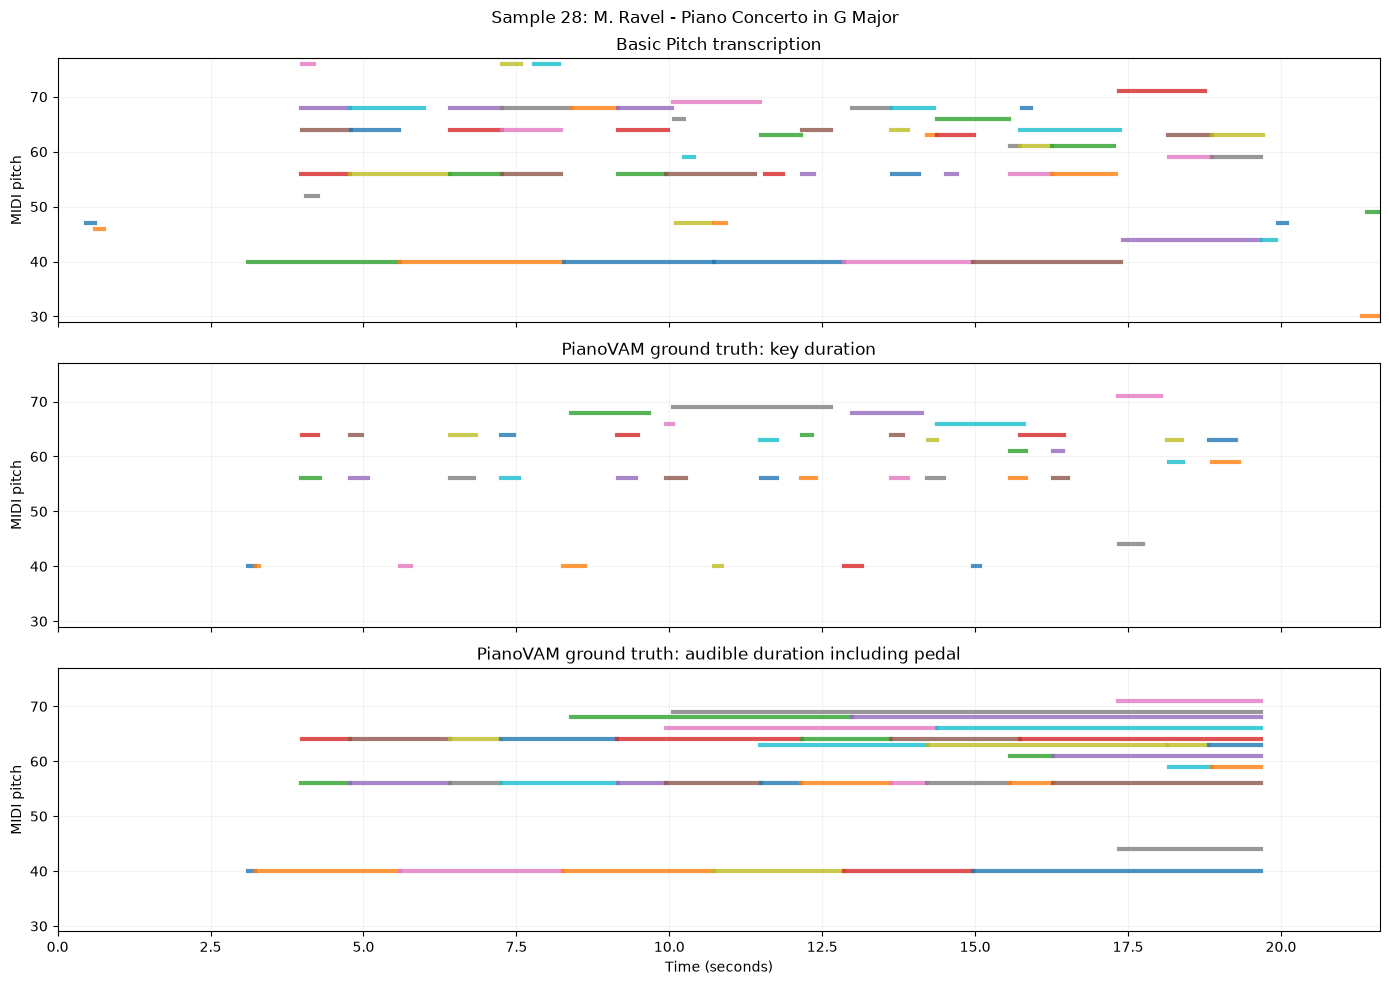

In [11]:
def plot_transcription_piano_roll(ground_truth_notes, predicted_notes, title=None):
    """
    Plot the Basic Pitch transcription and PianoVAM ground truth
    using key duration and audible duration.
    """

    fig, axes = plt.subplots(
        3,
        1,
        figsize=(14, 10),
        sharex=True
    )

    if title is not None:
        fig.suptitle(title)

    all_pitches = (
        [note["pitch"] for note in predicted_notes]
        + [note["pitch"] for note in ground_truth_notes]
    )

    pitch_min = min(all_pitches) - 1
    pitch_max = max(all_pitches) + 1

    all_times = (
        [note["offset"] for note in predicted_notes]
        + [note["frame_offset"] for note in ground_truth_notes]
    )

    time_max = max(all_times)

    for note in predicted_notes:
        axes[0].plot(
            [note["onset"], note["offset"]],
            [note["pitch"], note["pitch"]],
            linewidth=3,
            alpha=0.8
        )

    axes[0].set_title("Basic Pitch transcription")
    axes[0].set_ylabel("MIDI pitch")
    axes[0].grid(alpha=0.15)

    for note in ground_truth_notes:
        axes[1].plot(
            [note["onset"], note["key_offset"]],
            [note["pitch"], note["pitch"]],
            linewidth=3,
            alpha=0.8
        )

    axes[1].set_title("PianoVAM ground truth: key duration")
    axes[1].set_ylabel("MIDI pitch")
    axes[1].grid(alpha=0.15)

    for note in ground_truth_notes:
        axes[2].plot(
            [note["onset"], note["frame_offset"]],
            [note["pitch"], note["pitch"]],
            linewidth=3,
            alpha=0.8
        )

    axes[2].set_title(
        "PianoVAM ground truth: audible duration including pedal"
    )
    axes[2].set_xlabel("Time (seconds)")
    axes[2].set_ylabel("MIDI pitch")
    axes[2].grid(alpha=0.15)

    for ax in axes:
        ax.set_ylim(pitch_min, pitch_max)
        ax.set_xlim(0, time_max)

    plt.tight_layout()
    plt.show()


plot_transcription_piano_roll(
    ground_truth_notes = reference_notes,
    predicted_notes = predicted_notes,
    title=f"Sample {SELECTED_SAMPLE_ID}: {sample['composer']} - {sample['piece']}",
)

Using the training set to evaluate the performance of Basic Pitch (with default setting) on PianoVAM, hence try to find optimisation method.

In [12]:
def evaluate_on_pianovam(split_name):
    split_samples = metadata_df[
        (metadata_df["split"] == split_name)
        & (metadata_df["performance_method"] == "Solo")
    ].copy()

    rows = []

    for _, sample in split_samples.iterrows():
        paths = get_sample_paths(sample)
        reference_notes = load_ground_truth_notes(paths["tsv"])
        predicted_notes, runtime_seconds = transcribe_audio_cached(sample["sample_id"], paths["audio"])

        transcription_metrics = evaluate_note_transcription(
            reference_notes,
            predicted_notes,
        )
        transcription_output = analyse_transcription_output(
            reference_notes,
            predicted_notes,
        )

        result = {
            "sample_id": sample["sample_id"],
            "record_time": sample["record_time"],
            "composer": sample["composer"],
            "piece": sample["piece"],
            "duration_seconds": sample["duration_seconds"],
        }
        result.update(transcription_metrics)
        result.update(transcription_output)
        result["runtime_seconds"] = runtime_seconds

        rows.append(result)

    return pd.DataFrame(rows)

In [13]:
train_baseline_df = evaluate_on_pianovam("train")
train_baseline_df

,sample_id,record_time,composer,piece,duration_seconds,note_precision,note_recall,note_f1,note_precision_no_offset,note_recall_no_offset,...,transcription_extra_notes,transcription_wrong_pitch_notes,transcription_wrong_timing_notes,transcription_wrong_duration_notes,transcription_missing_chords,transcription_extra_chords,transcription_imperfect_chords,transcription_wrong_chords,transcription_output_is_correct,runtime_seconds
0,0,2024-02-14_19-10-09,E. Grieg,Piano Concerto,745.493,0.208801,0.166258,0.185117,0.738138,0.587743,...,225,404,695,850,130,21,1022,92,False,None
1,1,2024-02-14_19-44-26,N. Kapustin,Concert Etude No.6,493.653,0.235652,0.190494,0.210681,0.818224,0.661428,...,69,158,164,799,132,7,973,28,False,None
2,4,2024-02-14_20-37-55,M. Ravel,Piano Concerto in G Major,1101.205,0.222554,0.211285,0.216773,0.716584,0.680301,...,380,579,684,1470,181,52,1261,97,False,None
3,5,2024-02-14_20-58-43,M. Ravel,Piano Concerto for the Left Hand,1246.101,0.140977,0.160035,0.149902,0.611205,0.693831,...,435,886,2013,1818,77,83,506,78,False,None
4,6,2024-02-14_21-30-04,S. Rachmaninoff,Piano Concerto No.3,2547.413,0.177536,0.136092,0.154076,0.754784,0.578586,...,546,1525,3757,2890,637,60,4348,325,False,None
5,7,2024-02-15_15-13-10,R. Schumann,Fantasie Op.17,1158.869,0.169509,0.180586,0.174872,0.725630,0.773048,...,463,497,472,1489,43,59,1147,51,False,None
6,10,2024-02-15_20-28-13,M. Ravel,Piano Concerto in G Major,425.003,0.215221,0.148420,0.175685,0.743590,0.512792,...,59,268,868,657,284,9,963,97,False,None
7,13,2024-02-15_20-54-38,M. Ravel,Piano Concerto for the Left Hand,298.624,0.140609,0.149304,0.144826,0.580797,0.616713,...,89,367,909,626,36,16,102,21,False,None
8,14,2024-02-15_21-01-11,L. Beethoven,Piano Sonata No.23 Mvt.1,932.821,0.279066,0.226624,0.250126,0.724589,0.588423,...,186,617,1794,1649,253,28,1449,120,False,None
9,15,2024-02-15_21-18-14,L. Beethoven,Piano Sonata No.23 Mvt.1,813.589,0.244666,0.199482,0.219776,0.687093,0.560202,...,190,666,1747,1557,178,27,1297,178,False,None


standard metrics to evaluation the transcription

In [14]:
def summarise_amt_results(results_df):
    metric_columns = [
        "note_precision",
        "note_recall",
        "note_f1",
        "note_precision_no_offset",
        "note_recall_no_offset",
        "note_f1_no_offset",
        "note_average_overlap_with_offset",
        "runtime_seconds",
    ]

    summary = pd.DataFrame({
        "mean": results_df[metric_columns].mean(),
        "median": results_df[metric_columns].median(),
        "std": results_df[metric_columns].std(),
        "min": results_df[metric_columns].min(),
        "max": results_df[metric_columns].max(),
    })

    return summary

train_amt_summary = summarise_amt_results(train_baseline_df)
train_amt_summary

,mean,median,std,min,max
note_precision,0.209573,0.208801,0.065726,0.121212,0.444444
note_recall,0.209783,0.190494,0.068058,0.124523,0.445588
note_f1,0.207712,0.208949,0.062729,0.123727,0.412526
note_precision_no_offset,0.711776,0.719745,0.083046,0.514871,0.887577
note_recall_no_offset,0.712819,0.737346,0.093459,0.479736,0.913235
note_f1_no_offset,0.706003,0.718216,0.060824,0.586114,0.856248
note_average_overlap_with_offset,0.911386,0.916689,0.0299,0.82608,0.976537
runtime_seconds,NaN,NaN,NaN,None,None


Inspect the detailed results of the whole training set

In [15]:
analysis_columns = [
    "sample_id",
    "composer",
    "piece",
    "duration_seconds",
    "reference_notes",
    "predicted_notes",
    "note_precision",
    "note_recall",
    "note_f1",
    "note_f1_no_offset",
    "note_average_overlap_with_offset",
    "transcription_missing_notes",
    "transcription_extra_notes",
    "transcription_wrong_pitch_notes",
    "transcription_wrong_timing_notes",
    "transcription_wrong_duration_notes",
]

train_analysis_table = train_baseline_df[analysis_columns].sort_values(
    "note_f1_no_offset"
)
train_analysis_table

,sample_id,composer,piece,duration_seconds,reference_notes,predicted_notes,note_precision,note_recall,note_f1,note_f1_no_offset,note_average_overlap_with_offset,transcription_missing_notes,transcription_extra_notes,transcription_wrong_pitch_notes,transcription_wrong_timing_notes,transcription_wrong_duration_notes
12,19,E. Grieg,Piano Concerto,512.661,6810,4338,0.195482,0.124523,0.152135,0.586114,0.892193,571,87,346,634,609
7,13,M. Ravel,Piano Concerto for the Left Hand,298.624,1795,1906,0.140609,0.149304,0.144826,0.598217,0.920562,314,89,367,909,626
52,72,S. Rachmaninoff,Prelude Op.32 No.10,795.225,3240,4640,0.182974,0.262037,0.215482,0.606345,0.929487,11,1009,194,390,187
6,10,M. Ravel,Piano Concerto in G Major,425.003,5316,3666,0.215221,0.148420,0.175685,0.606992,0.918128,584,59,268,868,657
9,15,L. Beethoven,Piano Sonata No.23 Mvt.1,813.589,8106,6609,0.244666,0.199482,0.219776,0.617193,0.931696,688,190,666,1747,1557
19,27,M. Ravel,Piano Concerto for the Left Hand,1025.984,5785,5872,0.134877,0.136906,0.135884,0.619885,0.922516,676,315,889,2023,1592
11,18,E. Grieg,Piano Concerto,213.717,1298,1353,0.121212,0.126348,0.123727,0.622407,0.934980,69,143,104,220,93
46,56,Harold Arlen (arr. Rupert Austin),Over The Rainbow,1508.949,6524,8294,0.140463,0.178571,0.157241,0.623836,0.895299,285,890,664,774,1453
48,59,M. Ravel,Jeux D'eau,593.395,4702,4726,0.177529,0.178435,0.177980,0.625159,0.921334,429,274,469,1015,627
51,69,S. Rachmaninoff,Prelude Op.32 No.10,718.880,3036,4218,0.199147,0.276680,0.231596,0.636339,0.937298,4,872,164,280,130


Case studies for representative cases:
- lowest no-offset F1: weakest overall pitch/onset transcription --- sample id = 19
- lowest precision: most severe extra-note tendency --- sample id = 18
- lowest recall: most severe missed-note tendency --- sample id = 19
- highest no-offset F1: a strong baseline example --- sample id = 32

In [16]:
def run_case_study(sample_id):
    sample = metadata_df[metadata_df["sample_id"] == sample_id].iloc[0]
    paths = get_sample_paths(sample)

    reference_notes = load_ground_truth_notes(paths["tsv"])
    predicted_notes, _ = transcribe_audio_cached(sample_id, paths["audio"])

    plot_transcription_piano_roll(
        reference_notes,
        predicted_notes,
        title=f"Sample {sample_id}: {sample['composer']} - {sample['piece']}",
    )

    metrics = evaluate_note_transcription(reference_notes, predicted_notes)
    transcription_output = analyse_transcription_output(reference_notes, predicted_notes)

    result = {}
    result.update(metrics)
    result.update(transcription_output)

    return pd.Series(result)

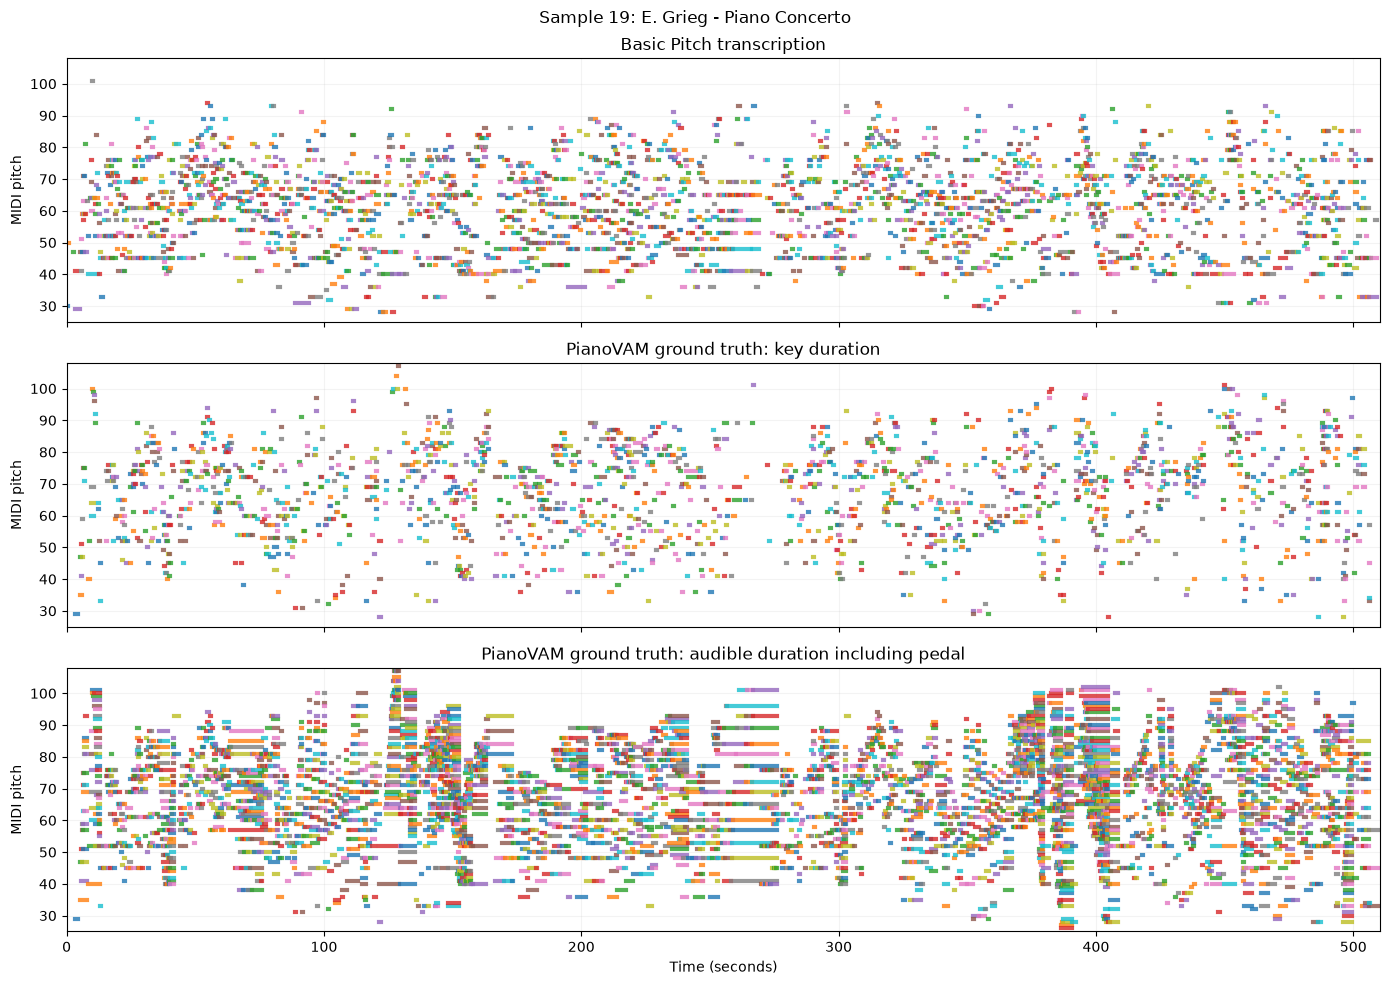

note_precision                        0.195482
note_recall                           0.124523
note_f1                               0.152135
note_precision_no_offset              0.753112
note_recall_no_offset                 0.479736
note_f1_no_offset                     0.586114
note_average_overlap_with_offset      0.892193
reference_notes                           6810
predicted_notes                           4338
note_count_difference                    -2472
transcription_missing_notes                571
transcription_extra_notes                   87
transcription_wrong_pitch_notes            346
transcription_wrong_timing_notes           634
transcription_wrong_duration_notes         609
transcription_missing_chords               284
transcription_extra_chords                  10
transcription_imperfect_chords            1078
transcription_wrong_chords                 104
transcription_output_is_correct          False
dtype: object

In [17]:
run_case_study("19")

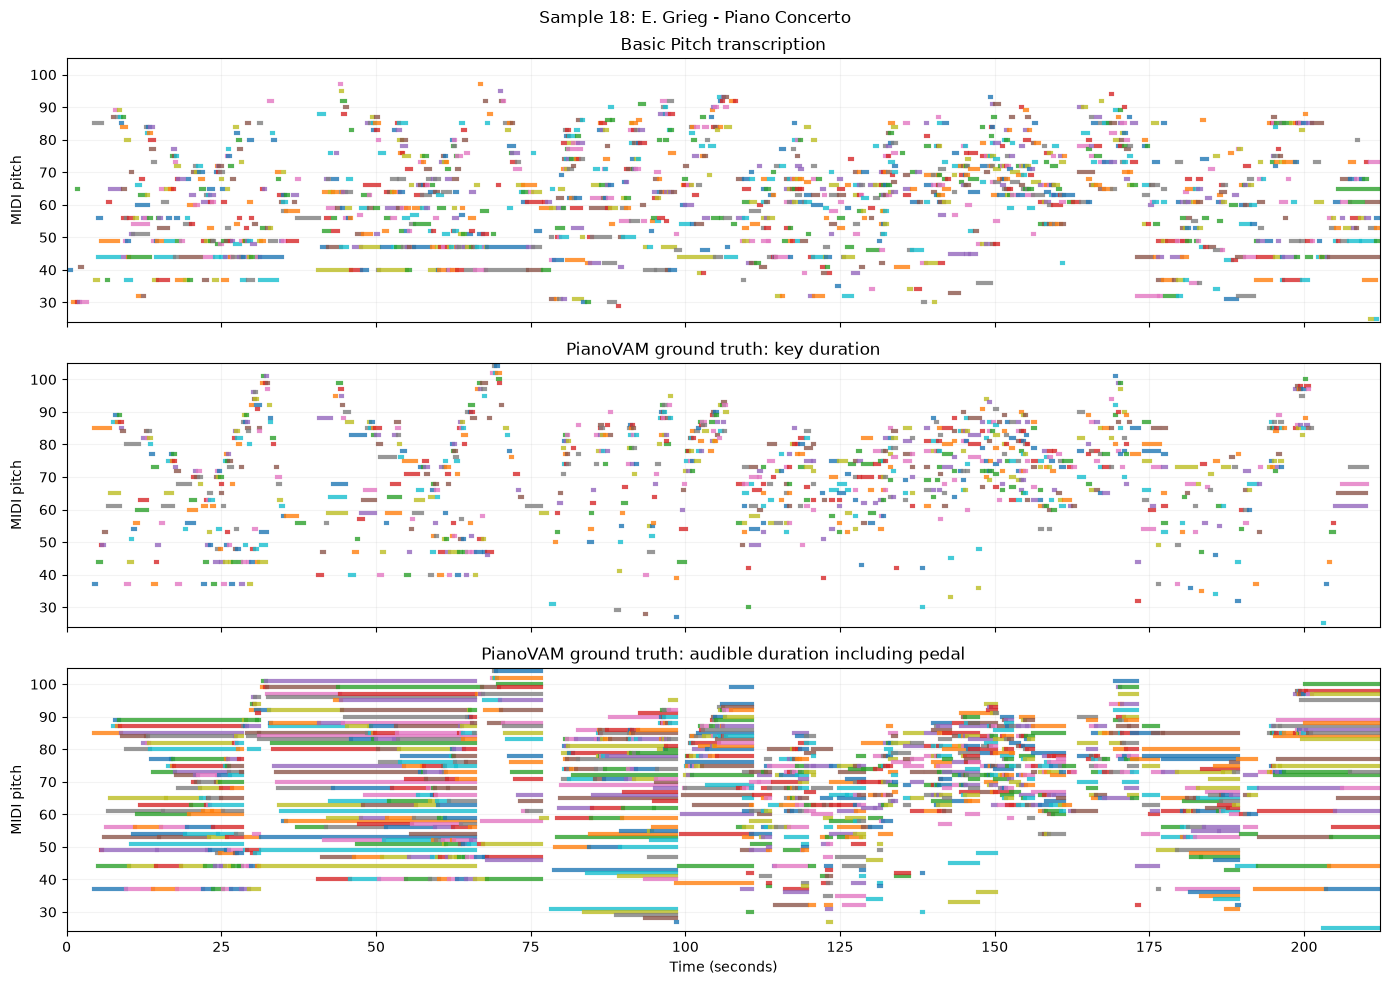

note_precision                        0.121212
note_recall                           0.126348
note_f1                               0.123727
note_precision_no_offset              0.609756
note_recall_no_offset                 0.635593
note_f1_no_offset                     0.622407
note_average_overlap_with_offset       0.93498
reference_notes                           1298
predicted_notes                           1353
note_count_difference                       55
transcription_missing_notes                 69
transcription_extra_notes                  143
transcription_wrong_pitch_notes            104
transcription_wrong_timing_notes           220
transcription_wrong_duration_notes          93
transcription_missing_chords                 7
transcription_extra_chords                  21
transcription_imperfect_chords             229
transcription_wrong_chords                  37
transcription_output_is_correct          False
dtype: object

In [18]:
run_case_study("18")

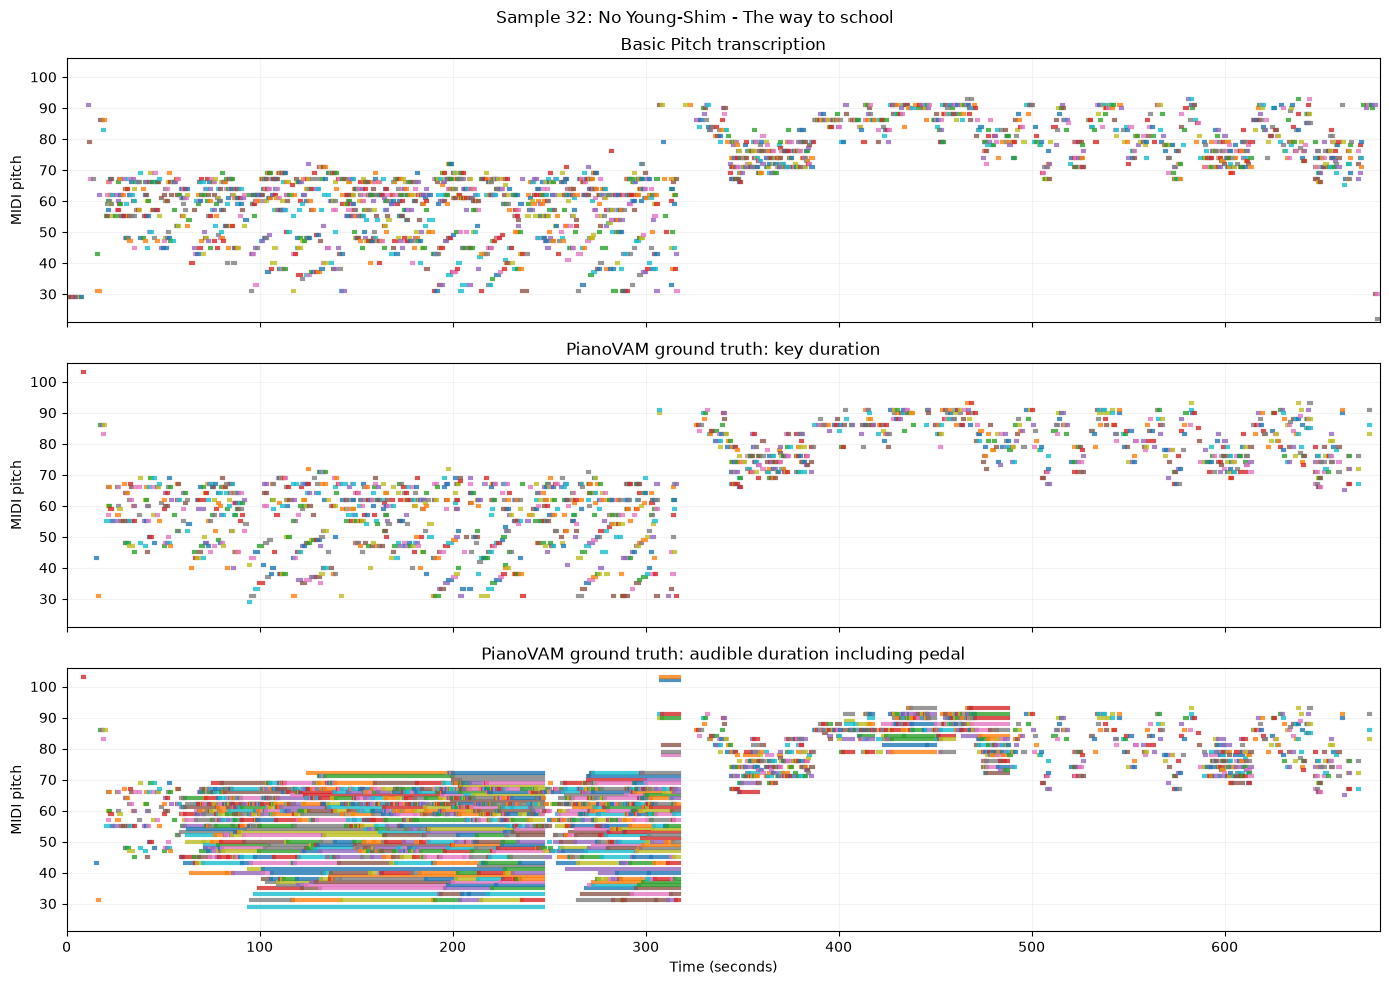

note_precision                        0.331661
note_recall                           0.309046
note_f1                               0.319954
note_precision_no_offset              0.887577
note_recall_no_offset                 0.827055
note_f1_no_offset                     0.856248
note_average_overlap_with_offset      0.939077
reference_notes                           3637
predicted_notes                           3389
note_count_difference                     -248
transcription_missing_notes                 66
transcription_extra_notes                   71
transcription_wrong_pitch_notes             79
transcription_wrong_timing_notes           348
transcription_wrong_duration_notes         776
transcription_missing_chords                21
transcription_extra_chords                   6
transcription_imperfect_chords             448
transcription_wrong_chords                   1
transcription_output_is_correct          False
dtype: object

In [19]:
run_case_study("32")

Baseline Analysis:

The note-level F-measure-no-offset (Fno) is chosen to be the main measure of overall note estimation accuracy as the definition of offsets is less objective due to reverberation, sustain pedal, annotation procedure.

The pretrained Basic Pitch model provides a reasonable baseline for automatic music transcription on the PianoVAM dataset since it successfully recovers most note onsets and pitches. However, qualitative inspection of the piano-roll visualisations reveals several systematic transcription errors.

Firstly, duration seems to be one of the biggest source of errors. While most predicted notes begin at approximately the correct time, their offsets differ from the ground truth even though the frame-offset has already been used with the consideration of audible duration. This observation is also reflected in the large gap between the metrics with and without involving offset comparison.

Secondly, can observe from the pianoroll that the transcription contains some pre-performance non-musical sounds. Also, many sustained notes are fragmented into multiple short notes with identical pitches. This behaviour is particularly noticeable in pieces with extensive sustain pedal usage, where a single musical note is represented by several consecutive predictions instead of one continuous note. 

Thirdly, by listening to some transcriptions, can find that they often sound more 'continuous' and 'noisy' than the ground truth, this may be due to pedal noise, some sympathetic resonance, piano overtones are recognized as independent notes.

Overall, these observations suggest that the pretrained model already provides reliable onset localisation but suffers from systematic post-processing limitations, particularly in duration estimation and note segmentation. Therefore, rather than starting to retrain the neural network right away, will focus on improving the transcription through implementing dedicated post-processing steps.

## post-processing experiments

Calibrate the Basic Pitch model for the music practice recording.

**Part 1** jointly tunes the four existing Basic Pitch decoder parameters on the complete Solo training split, evaluated mainly based on median and mean note-level F1 without offset (`note_f1_no_offset`). 

**Part 2** task-specific post-processing calibrations
- remove predictions before the likely performance start;
- merge fragmentations;
- investigate pedal-aware offset handling;

Evaluated using the same training set, same AMT metrics and case studies.

part1

In [20]:
from sklearn.model_selection import ParameterSampler

# the best config on the validation set is 
# {'onset_threshold': 0.7, 'frame_threshold': 0.2, 'minimum_note_length': 75.0, 'melodia_trick': False}
# default config for Basic Pitch is: onset_threshold=0.5, frame_threshold=0.3
param_grid = {
    "onset_threshold": [0.5, 0.6, 0.7, 0.8],
    "frame_threshold": [0.1, 0.15, 0.2, 0.3],
    "minimum_note_length": [50, 75, 100, 150],
    "melodia_trick": [False],
}

parameter_sets = list(ParameterSampler(param_grid, n_iter=40, random_state=42))

train_samples = metadata_df[
    (metadata_df["split"] == "train")
    & (metadata_df["performance_method"] == "Solo")
].copy()

print("training samples:", len(train_samples))

training samples: 53


In [21]:
def evaluate_tuned_configuration(config):
    rows = []
    predictions = {}

    for _, sample in tqdm(train_samples.iterrows(), total=len(train_samples), desc="Tuned evaluation"):
        paths = get_sample_paths(sample)
        reference_notes = load_ground_truth_notes(paths["tsv"])
        predicted_notes, _, _ = transcribe_audio(paths["audio"], **config)

        metrics = evaluate_note_transcription(reference_notes, predicted_notes)
        output = analyse_transcription_output(reference_notes, predicted_notes)
        rows.append({"sample_id": sample["sample_id"], **metrics, **output})
        predictions[str(sample["sample_id"])] = predicted_notes

    return pd.DataFrame(rows), predictions

In [23]:
CHECKPOINT_EVERY = 10  # reload the model every N samples to bound memory growth
SEARCH_PROGRESS_PATH = OUTPUT_DIR / "random_search_progress.csv"

def load_completed_sample_ids(path):
    """Return sample_ids that already have results saved from a previous run."""
    if not path.exists():
        return set()
    existing_df = pd.read_csv(path)
    return set(existing_df["sample_id"].astype(str))


completed_sample_ids = load_completed_sample_ids(SEARCH_PROGRESS_PATH)
remaining_samples = train_samples[~train_samples["sample_id"].astype(str).isin(completed_sample_ids)]

for sample_index, (_, sample) in enumerate(
    tqdm(remaining_samples.iterrows(), total=len(remaining_samples), desc="Random search")
):
    paths = get_sample_paths(sample)
    reference_notes = load_ground_truth_notes(paths["tsv"])

    # Suppress Basic Pitch's internal print/warning output, same as transcribe_audio does,
    # so it does not clutter the tqdm progress bar.
    hidden_output = io.StringIO()
    with contextlib.redirect_stdout(hidden_output), contextlib.redirect_stderr(hidden_output):
        model_output = run_inference(paths["audio"], basic_pitch_model)

    sample_rows = []
    for config_id, config in enumerate(parameter_sets):
        predicted_notes = decode_model_output(model_output, config)
        metrics = evaluate_note_transcription(reference_notes, predicted_notes)
        sample_rows.append({
            "config_id": config_id,
            "sample_id": sample["sample_id"],
            **config,
            **metrics,
        })

    # Append this sample's results to disk right away, so a crash later on
    # does not lose the work already done for this sample.
    sample_df = pd.DataFrame(sample_rows)
    write_header = not SEARCH_PROGRESS_PATH.exists()
    sample_df.to_csv(SEARCH_PROGRESS_PATH, mode="a", header=write_header, index=False)

    # Release this sample's raw model output before moving on
    del model_output
    gc.collect()

    # Periodically recreate the Basic Pitch model object. TensorFlow keeps
    # caching a new computation graph every time it sees a differently-shaped
    # input (here, every audio file with a different duration), and this
    # cache is never released on its own. Recreating the Model object lets
    # the old cached graphs be garbage-collected, which prevents memory from
    # growing without bound over a long run.
    if (sample_index + 1) % CHECKPOINT_EVERY == 0:
        basic_pitch_model = Model(ICASSP_2022_MODEL_PATH)
        gc.collect()

search_details = pd.read_csv(SEARCH_PROGRESS_PATH)
random_search_results = (
    search_details
    .groupby([
        "config_id",
        "onset_threshold",
        "frame_threshold",
        "minimum_note_length",
        "melodia_trick",
    ], as_index=False)
    .agg(
        note_precision_no_offset=("note_precision_no_offset", "mean"),
        note_recall_no_offset=("note_recall_no_offset", "mean"),
        note_f1_no_offset=("note_f1_no_offset", "mean"),
        note_f1_with_offset=("note_f1", "mean"),
        predicted_notes=("predicted_notes", "mean"),
    )
    .sort_values(
        ["note_f1_no_offset", "note_precision_no_offset", "note_recall_no_offset"],
        ascending=False,
    )
    .reset_index(drop=True)
)

random_search_results

Random search: 100%|██████████| 50/50 [1:54:55<00:00, 137.91s/it]  


,config_id,onset_threshold,frame_threshold,minimum_note_length,melodia_trick,note_precision_no_offset,note_recall_no_offset,note_f1_no_offset,note_f1_with_offset,predicted_notes
0,18,0.6,0.30,50,False,0.848710,0.754585,0.795786,0.239228,5830.018868
1,15,0.7,0.30,50,False,0.909930,0.682198,0.775713,0.232950,4911.773585
2,39,0.6,0.30,100,False,0.872970,0.702199,0.774564,0.236325,5262.962264
3,21,0.6,0.20,50,False,0.769867,0.782939,0.773516,0.261775,6655.924528
4,26,0.6,0.20,100,False,0.802609,0.751959,0.773477,0.264881,6140.716981
5,25,0.7,0.30,75,False,0.917976,0.670073,0.770562,0.232926,4780.811321
6,0,0.5,0.30,75,False,0.772857,0.773270,0.769865,0.224673,6572.773585
7,14,0.7,0.20,50,False,0.860299,0.698792,0.767303,0.259635,5309.773585
8,34,0.7,0.15,100,False,0.848311,0.689248,0.756918,0.278030,5314.283019
9,10,0.5,0.30,100,False,0.789472,0.731062,0.755239,0.222078,6069.037736


In [24]:
best_config = random_search_results.iloc[0]

TUNED_CONFIG = {
    "onset_threshold": float(best_config["onset_threshold"]),
    "frame_threshold": float(best_config["frame_threshold"]),
    "minimum_note_length": float(best_config["minimum_note_length"]),
    "melodia_trick": bool(best_config["melodia_trick"]),
}

train_tuned_df, tuned_predictions = evaluate_tuned_configuration(TUNED_CONFIG)
TUNED_CONFIG

Tuned evaluation: 100%|██████████| 53/53 [22:45<00:00, 25.76s/it] 


{'onset_threshold': 0.6,
 'frame_threshold': 0.3,
 'minimum_note_length': 50.0,
 'melodia_trick': False}

In [25]:
def comparison_row(name, results):
    return {
        "configuration": name,
        "mean_note_precision_no_offset": results["note_precision_no_offset"].mean(),
        "median_note_precision_no_offset": results["note_precision_no_offset"].median(),
        "mean_note_recall_no_offset": results["note_recall_no_offset"].mean(),
        "median_note_recall_no_offset": results["note_recall_no_offset"].median(),
        "mean_note_f1_no_offset": results["note_f1_no_offset"].mean(),
        "median_note_f1_no_offset": results["note_f1_no_offset"].median(),
        "mean_note_f1_with_offset": results["note_f1"].mean(),
        "mean_predicted_notes": results["predicted_notes"].mean(),
        "mean_extra_notes": results["transcription_extra_notes"].mean(),
        "mean_missing_notes": results["transcription_missing_notes"].mean(),
    }

part1_comparison = pd.DataFrame([
    comparison_row("Default Basic Pitch", train_baseline_df),
    comparison_row("Tuned Basic Pitch", train_tuned_df),
])

part1_comparison

,configuration,mean_note_precision_no_offset,median_note_precision_no_offset,mean_note_recall_no_offset,median_note_recall_no_offset,mean_note_f1_no_offset,median_note_f1_no_offset,mean_note_f1_with_offset,mean_predicted_notes,mean_extra_notes,mean_missing_notes
0,Default Basic Pitch,0.711776,0.719745,0.712819,0.737346,0.706003,0.718216,0.207712,6532.150943,369.056604,425.622642
1,Tuned Basic Pitch,0.848710,0.857649,0.754585,0.758952,0.795786,0.800000,0.239228,5830.018868,26.169811,433.679245


part2

Post-processing comparison helpers

These functions evaluate a sample from the cached raw predictions, optionally passing the predicted notes through a post-processing function first. This is the building block for before/after post-processing comparisons in the case studies below.

In [ ]:
def evaluate_with_postprocessing(sample_id, postprocess_fn=None):
    """
    Evaluate one sample using cached raw Basic Pitch predictions.

    postprocess_fn: a function that takes a list of predicted notes and
        returns a new (post-processed) list of predicted notes. If None,
        the raw predictions are evaluated directly -- this is the "before"
        case for before/after post-processing comparisons.
    """
    sample = metadata_df[metadata_df["sample_id"] == sample_id].iloc[0]
    paths = get_sample_paths(sample)

    reference_notes = load_ground_truth_notes(paths["tsv"])
    predicted_notes, _, _ = transcribe_audio(paths["audio"], **TUNED_CONFIG)

    if postprocess_fn is not None:
        predicted_notes = postprocess_fn(predicted_notes)

    metrics = evaluate_note_transcription(reference_notes, predicted_notes)
    transcription_output = analyse_transcription_output(reference_notes, predicted_notes)

    result = {"sample_id": sample_id}
    result.update(metrics)
    result.update(transcription_output)

    return pd.Series(result)


def compare_before_after_postprocessing(sample_id, postprocess_fn):
    """
    Run one sample before and after a post-processing function.

    Returns a DataFrame with two rows ("before", "after") plus a "delta"
    row (after - before) for all numeric columns, e.g. delta of
    transcription_missing_notes tells you whether this post-processing
    step reduced missing notes for this sample.
    """
    before = evaluate_with_postprocessing(sample_id, postprocess_fn=None)
    after = evaluate_with_postprocessing(sample_id, postprocess_fn=postprocess_fn)

    comparison_df = pd.DataFrame([before, after], index=["before", "after"])

    numeric_columns = comparison_df.select_dtypes(include="number").columns
    comparison_df.loc["delta", numeric_columns] = (
        comparison_df.loc["after", numeric_columns] - comparison_df.loc["before", numeric_columns]
    )

    return comparison_df